<a href="https://colab.research.google.com/github/awrunpatel/django-dashub/blob/main/Seminar_6_Big_Data2_Streaming.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [62]:
# -----------------------------------
# This cell loads the core libraries we need for:
# - making live API requests
# - storing incoming data
# - computing rolling windows
# - plotting the live stream

import requests
import pandas as pd
import time
import matplotlib.pyplot as plt
from datetime import datetime

# Set plot style for consistency
plt.style.use("seaborn-v0_8")

# Kathmandu coordinates (Nepal)
latitude = 27.7172
longitude = 85.3240

print("Streaming Tutorial Initialised")
print(f"Location set to Kathmandu (lat={latitude}, lon={longitude})")

Streaming Tutorial Initialised
Location set to Kathmandu (lat=27.7172, lon=85.324)


In [63]:
# -----------------------------------------
# We use the Open-Meteo API because:
# - it is free
# - it requires no API key
# - it updates every minute
# - it returns clean JSON data

api_url = (
    f"https://api.open-meteo.com/v1/forecast?"
    f"latitude={latitude}&longitude={longitude}&current_weather=true"
)

print("API endpoint configured:")
print(api_url)

API endpoint configured:
https://api.open-meteo.com/v1/forecast?latitude=27.7172&longitude=85.324&current_weather=true


In [64]:
# --------------------------------------------
# This function:
# - sends a request to the API
# - extracts the current weather fields
# - returns a dictionary with timestamp + temperature + windspeed

def fetch_weather():
    response = requests.get(api_url)
    data = response.json()

    current = data["current_weather"]

    return {
        "timestamp": datetime.fromisoformat(current["time"]),
        "temperature": current["temperature"],
        "windspeed": current["windspeed"],
        "winddirection": current["winddirection"]
    }

print("Live weather fetch function ready.")

Live weather fetch function ready.


In [65]:
# ------------------------------------
# This DataFrame will grow as new readings arrive.
# It acts like a streaming buffer or micro-batch store.

stream_df = pd.DataFrame(columns=[
    "timestamp", "temperature", "windspeed", "winddirection"
])

print("Empty streaming DataFrame created.")

Empty streaming DataFrame created.


In [49]:
# Start a simple streaming loop that:
# - polls the live API every few seconds
# - appends the new reading to the streaming DataFrame
# - prints the latest reading for visibility

stream_duration_seconds = 300   # total time to stream
poll_interval_seconds = 10     # fetch new data every 10 seconds

start_time = time.time()

print("Starting live weather stream...")

while time.time() - start_time < stream_duration_seconds:
    reading = fetch_weather()
    # OVERRIDE the timestamp with current time to ensure unique, increasing values
    # for proper Dask time-series operations, as the API's reported time might be static
    # or the same across multiple rapid polls.
    reading['timestamp'] = datetime.now()
    stream_df.loc[len(stream_df)] = reading
    print(f"New reading: {reading['timestamp']} | Temp: {reading['temperature']}°C")
    time.sleep(poll_interval_seconds)

print("Streaming complete.")

Starting live weather stream...
New reading: 2026-04-28 11:22:35.852917 | Temp: 21.0°C
New reading: 2026-04-28 11:22:46.309435 | Temp: 21.0°C
New reading: 2026-04-28 11:22:56.762734 | Temp: 21.0°C
New reading: 2026-04-28 11:23:07.230544 | Temp: 21.0°C
New reading: 2026-04-28 11:23:17.685678 | Temp: 21.0°C
New reading: 2026-04-28 11:23:28.139976 | Temp: 21.0°C
New reading: 2026-04-28 11:23:38.614132 | Temp: 21.0°C
New reading: 2026-04-28 11:23:49.067279 | Temp: 21.0°C
New reading: 2026-04-28 11:23:59.520427 | Temp: 21.0°C
New reading: 2026-04-28 11:24:09.990750 | Temp: 21.0°C
New reading: 2026-04-28 11:24:20.471065 | Temp: 21.0°C
New reading: 2026-04-28 11:24:30.957446 | Temp: 21.0°C
New reading: 2026-04-28 11:24:41.431931 | Temp: 21.0°C
New reading: 2026-04-28 11:24:51.895599 | Temp: 21.0°C
New reading: 2026-04-28 11:25:02.366072 | Temp: 21.0°C
New reading: 2026-04-28 11:25:12.826018 | Temp: 21.0°C
New reading: 2026-04-28 11:25:23.294238 | Temp: 21.0°C
New reading: 2026-04-28 11:25:33.

In [50]:
stream_df.head()

,timestamp,temperature,windspeed,winddirection
0,2026-04-28 11:22:35.852917,21.0,1.7,283
1,2026-04-28 11:22:46.309435,21.0,1.7,283
2,2026-04-28 11:22:56.762734,21.0,1.7,283
3,2026-04-28 11:23:07.230544,21.0,1.7,283
4,2026-04-28 11:23:17.685678,21.0,1.7,283


In [51]:
stream_df.shape

(29, 4)

In [52]:
# Restore timestamp as a normal column if it is currently the index
if "timestamp" not in stream_df.columns:
    stream_df = stream_df.reset_index().rename(columns={"index": "timestamp"})

# Ensure timestamp is datetime
stream_df["timestamp"] = pd.to_datetime(stream_df["timestamp"])

# IMPORTANT: Sort the DataFrame by timestamp to ensure Dask can establish known divisions
# for time-based operations like rolling windows.
stream_df = stream_df.sort_values(by="timestamp").reset_index(drop=True)

# Create a Dask DataFrame from the pandas stream, setting the timestamp as index directly
import dask.dataframe as dd

num_partitions = 2

# Set the timestamp as the index in the pandas DataFrame first
stream_df_indexed = stream_df.set_index("timestamp")

# Create the Dask DataFrame directly with the desired number of partitions.
# Dask will infer divisions because stream_df_indexed has a sorted datetime index.
dask_stream = dd.from_pandas(stream_df_indexed, npartitions=num_partitions).persist()

print("Dask streaming DataFrame created and partitioned into 2 partitions.")
print(dask_stream)
print("Dask DataFrame Divisions:", dask_stream.divisions)

Dask streaming DataFrame created and partitioned into 2 partitions.
Dask DataFrame Structure:
                           temperature windspeed winddirection
npartitions=2                                                 
2026-04-28 11:22:35.852917     float64   float64         int64
2026-04-28 11:25:12.826018         ...       ...           ...
2026-04-28 11:27:28.960708         ...       ...           ...
Dask Name: frompandas, 1 expression
Expr=FromGraph(5991cb6)
Dask DataFrame Divisions: (Timestamp('2026-04-28 11:22:35.852917'), Timestamp('2026-04-28 11:25:12.826018'), Timestamp('2026-04-28 11:27:28.960708'))


In [53]:
# Compute a 2-minute rolling mean across the Dask partitions.
# A shorter window is used here because the stream is only 1 minute long.
# This demonstrates how Dask performs time-based rolling across partitions.

rolling_temp = (
    dask_stream["temperature"]
      .rolling("2min")
      .mean()
      .compute()
)

rolling_wind = (
    dask_stream["windspeed"]
    .rolling("2min")
    .mean()
    .compute()
)

print("Rolling window (2-minute) computed.")
print("\nTemperature rolling mean:")
print(rolling_temp)

print("\nWindspeed rolling mean:")
print(rolling_wind)

Rolling window (2-minute) computed.

Temperature rolling mean:
timestamp
2026-04-28 11:22:35.852917    21.0
2026-04-28 11:22:46.309435    21.0
2026-04-28 11:22:56.762734    21.0
2026-04-28 11:23:07.230544    21.0
2026-04-28 11:23:17.685678    21.0
2026-04-28 11:23:28.139976    21.0
2026-04-28 11:23:38.614132    21.0
2026-04-28 11:23:49.067279    21.0
2026-04-28 11:23:59.520427    21.0
2026-04-28 11:24:09.990750    21.0
2026-04-28 11:24:20.471065    21.0
2026-04-28 11:24:30.957446    21.0
2026-04-28 11:24:41.431931    21.0
2026-04-28 11:24:51.895599    21.0
2026-04-28 11:25:02.366072    21.0
2026-04-28 11:25:12.826018    21.0
2026-04-28 11:25:23.294238    21.0
2026-04-28 11:25:33.761913    21.0
2026-04-28 11:25:44.229308    21.0
2026-04-28 11:25:54.701509    21.0
2026-04-28 11:26:05.166442    21.0
2026-04-28 11:26:15.631326    21.0
2026-04-28 11:26:26.120589    21.0
2026-04-28 11:26:36.587695    21.0
2026-04-28 11:26:47.073908    21.0
2026-04-28 11:26:57.547363    21.0
2026-04-28 11:27:

In [54]:
# Check how many partitions the Dask streaming DataFrame currently has
print("Number of partitions:", dask_stream.npartitions)

Number of partitions: 2


In [55]:
# Inspect how Dask has split the streaming data across partitions.
# This is important for understanding how rolling windows behave across boundaries.

for i in range(dask_stream.npartitions):
    part = dask_stream.get_partition(i).compute()
    print(f"\n--- Partition {i} ---")
    print(part)


--- Partition 0 ---
                            temperature  windspeed  winddirection
timestamp                                                        
2026-04-28 11:22:35.852917         21.0        1.7            283
2026-04-28 11:22:46.309435         21.0        1.7            283
2026-04-28 11:22:56.762734         21.0        1.7            283
2026-04-28 11:23:07.230544         21.0        1.7            283
2026-04-28 11:23:17.685678         21.0        1.7            283
2026-04-28 11:23:28.139976         21.0        1.7            283
2026-04-28 11:23:38.614132         21.0        1.7            283
2026-04-28 11:23:49.067279         21.0        1.7            283
2026-04-28 11:23:59.520427         21.0        1.7            283
2026-04-28 11:24:09.990750         21.0        1.7            283
2026-04-28 11:24:20.471065         21.0        1.7            283
2026-04-28 11:24:30.957446         21.0        1.7            283
2026-04-28 11:24:41.431931         21.0        1.7     

In [56]:
# Compute a 2-minute rolling mean across the Dask partitions.
# A shorter window is used here because the stream is only 1 minute long.
# This demonstrates how Dask performs time-based rolling across partitions.

rolling_temp = (
    dask_stream["temperature"]
    .rolling("2min")
    .mean()
    .compute()
)

rolling_wind = (
    dask_stream["windspeed"]
    .rolling("2min")
    .mean()
    .compute()
)

print("Rolling window (2-minute) computed.")
print("\nTemperature rolling mean:")
print(rolling_temp)

print("\nWindspeed rolling mean:")
print(rolling_wind)

Rolling window (2-minute) computed.

Temperature rolling mean:
timestamp
2026-04-28 11:22:35.852917    21.0
2026-04-28 11:22:46.309435    21.0
2026-04-28 11:22:56.762734    21.0
2026-04-28 11:23:07.230544    21.0
2026-04-28 11:23:17.685678    21.0
2026-04-28 11:23:28.139976    21.0
2026-04-28 11:23:38.614132    21.0
2026-04-28 11:23:49.067279    21.0
2026-04-28 11:23:59.520427    21.0
2026-04-28 11:24:09.990750    21.0
2026-04-28 11:24:20.471065    21.0
2026-04-28 11:24:30.957446    21.0
2026-04-28 11:24:41.431931    21.0
2026-04-28 11:24:51.895599    21.0
2026-04-28 11:25:02.366072    21.0
2026-04-28 11:25:12.826018    21.0
2026-04-28 11:25:23.294238    21.0
2026-04-28 11:25:33.761913    21.0
2026-04-28 11:25:44.229308    21.0
2026-04-28 11:25:54.701509    21.0
2026-04-28 11:26:05.166442    21.0
2026-04-28 11:26:15.631326    21.0
2026-04-28 11:26:26.120589    21.0
2026-04-28 11:26:36.587695    21.0
2026-04-28 11:26:47.073908    21.0
2026-04-28 11:26:57.547363    21.0
2026-04-28 11:27:

Why Rolling Windows Matter in Streaming
Rolling windows let you compute statistics over the most recent slice of time, not the entire history. This makes them essential for streaming systems because they provide:
- Smoothing of noisy signals — stabilises rapidly changing sensor or event data.
- Short‑term trend detection — shows what’s happening right now, not hours ago.
- Anomaly detection — flags spikes or drops relative to recent behaviour.
- Windowed aggregations — core to real‑time analytics in Dask, Spark, Flink, and Kafka Streams.


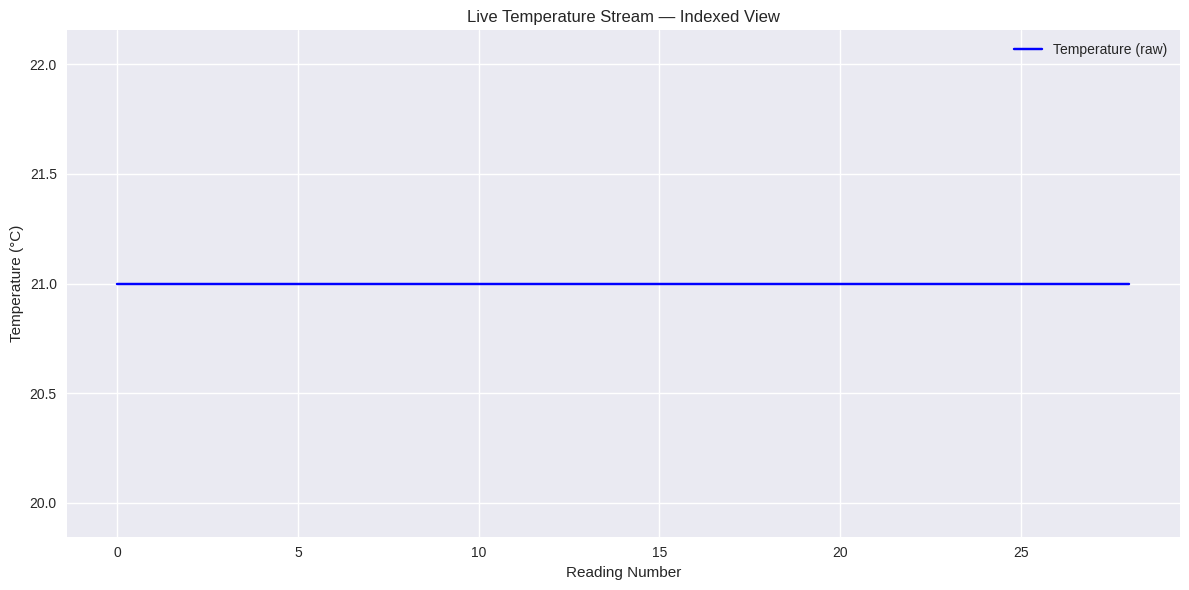

In [57]:
# Plot temperature using row index instead of timestamp.
# This guarantees a visible plot even when all timestamps are identical.

plt.figure(figsize=(12, 6))

plt.plot(range(len(stream_df)), stream_df["temperature"],
         label="Temperature (raw)", color="blue")

plt.title("Live Temperature Stream — Indexed View")
plt.xlabel("Reading Number")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [58]:
import pandas as pd
import dask.dataframe as dd

# Start with the existing stream_df from your indexed plot
master_df = stream_df.copy()

print("Starting micro-batch ingestion...\n")

batch_size = 5
num_batches = 4

for batch in range(num_batches):
    # Create a micro-batch of identical readings
    batch_df = pd.DataFrame({
        "timestamp": [pd.Timestamp("2026-04-18 14:30:00")] * batch_size,
        "temperature": [16.5] * batch_size,
        "windspeed": [5.2] * batch_size,
        "winddirection": [180] * batch_size
    })

    print(f"Ingesting batch {batch+1}/{num_batches} with {batch_size} rows")

    # Append to master DataFrame
    master_df = pd.concat([master_df, batch_df], ignore_index=True)

    # Convert to Dask and force 2 partitions
    dask_stream = dd.from_pandas(master_df, npartitions=1)
    dask_stream = dask_stream.set_index("timestamp")
    dask_stream = dask_stream.repartition(npartitions=2, force=True).persist()

    print("Total rows:", len(master_df))
    print("Partitions:", dask_stream.npartitions)
    print("-" * 40)

Starting micro-batch ingestion...

Ingesting batch 1/4 with 5 rows
Total rows: 34
Partitions: 2
----------------------------------------
Ingesting batch 2/4 with 5 rows
Total rows: 39
Partitions: 2
----------------------------------------
Ingesting batch 3/4 with 5 rows
Total rows: 44
Partitions: 2
----------------------------------------
Ingesting batch 4/4 with 5 rows
Total rows: 49
Partitions: 2
----------------------------------------


In [59]:
import numpy as np

# Copy the current master_df so we don't overwrite the original
var_df = master_df.copy()

# Add small random noise to temperature
var_df["temperature"] = (
    var_df["temperature"].astype(float)
    + np.random.normal(0, 0.2, len(var_df))      # natural noise
    + np.linspace(0, 0.5, len(var_df))           # slow drift across the stream
)

# Add noise to windspeed
var_df["windspeed"] = (
    var_df["windspeed"].astype(float)
    + np.random.normal(0, 0.3, len(var_df))
)

# Add wobble to wind direction
var_df["winddirection"] = (
    var_df["winddirection"].astype(float)
    + np.random.normal(0, 5, len(var_df))
)

# Optional: inject a rare anomaly spike
if np.random.rand() < 0.15:
    spike_idx = np.random.randint(0, len(var_df))
    var_df.loc[spike_idx, "temperature"] += np.random.uniform(2, 5)
    print(f"Injected anomaly spike at index {spike_idx}")

print("Variation added to the stream.")

Variation added to the stream.


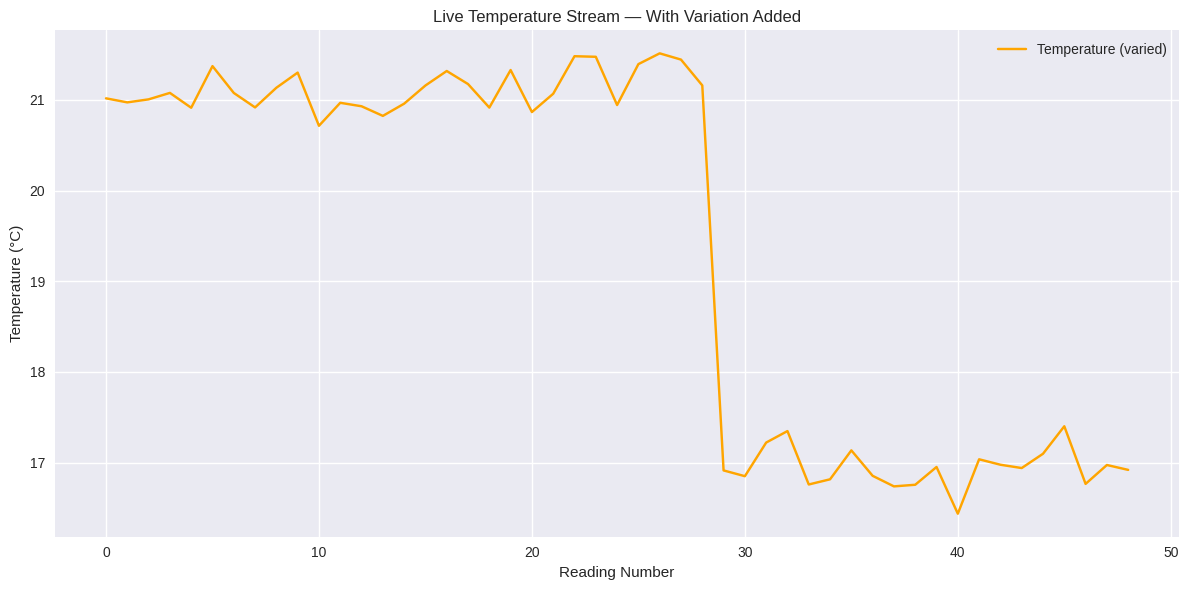

In [60]:
plt.figure(figsize=(12, 6))

plt.plot(range(len(var_df)), var_df["temperature"],
         label="Temperature (varied)", color="orange")

plt.title("Live Temperature Stream — With Variation Added")
plt.xlabel("Reading Number")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [61]:
# Detect anomalies per micro-batch using the varied data
batch_size = 5
num_batches = len(var_df) // batch_size

anomalies = []

print("Starting anomaly detection...\n")

for batch in range(num_batches):
    start = batch * batch_size
    end = start + batch_size
    batch_data = var_df.iloc[start:end]

    mean_temp = batch_data["temperature"].mean()
    std_temp = batch_data["temperature"].std()

    # Rule: anomaly if > 2 standard deviations from batch mean
    threshold_high = mean_temp + 2 * std_temp
    threshold_low = mean_temp - 2 * std_temp

    batch_anomalies = batch_data[
        (batch_data["temperature"] > threshold_high) |
        (batch_data["temperature"] < threshold_low)
    ]

    if not batch_anomalies.empty:
        print(f"Anomaly detected in batch {batch+1}:")
        print(batch_anomalies)
        anomalies.append(batch_anomalies)
    else:
        print(f"No anomalies in batch {batch+1}.")

Starting anomaly detection...

No anomalies in batch 1.
No anomalies in batch 2.
No anomalies in batch 3.
No anomalies in batch 4.
No anomalies in batch 5.
No anomalies in batch 6.
No anomalies in batch 7.
No anomalies in batch 8.
No anomalies in batch 9.


In [66]:
import requests
import pandas as pd

def get_city_weather(city_name, lat, lon):
    url = f"https://api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}&current_weather=true"
    response = requests.get(url).json()
    current = response['current_weather']
    return {
        'City': city_name,
        'Temperature (°C)': current['temperature'],
        'Windspeed (km/h)': current['windspeed'],
        'Wind Direction': current['winddirection'],
        'Weather Code': current['weathercode']
    }

# Coordinates for both locations
locations = [
    ("Kathmandu, Nepal", 27.7172, 85.3240),
    ("Birmingham, UK", 52.4862, -1.8904)
]

# Fetch data for all locations
weather_data = [get_city_weather(name, lat, lon) for name, lat, lon in locations]

# Display as a DataFrame for easy comparison
comparison_df = pd.DataFrame(weather_data)
display(comparison_df)

,City,Temperature (°C),Windspeed (km/h),Wind Direction,Weather Code
0,"Kathmandu, Nepal",21.0,1.7,283,3
1,"Birmingham, UK",10.2,19.8,52,3
